# WaveSlide - EDA

### Collaborators:
- Raul Andres Cerreño Zeballos
- Leicy Cristel Cahuana Lopez
- Diego Fabrizio Mucha Alvarez

## 1. Introduction

**This notebook covers the stages 1, 2 and 3 of the CRISP-DM methodology.**

The EDA analyzes the image dataset used for WaveSlide. WaveSlide is a computer vision project focused on taking the need away of presentators to have a helper to control their presentation. For the data, the HaGRID dataset will be used, a dataset composed of variuos images of persons doing a certain gesture. This analysis will be focused on checking the quality of the data, class distribution, bounding boxes, intensity histograms, and possible preprocessing strategies.

WaveSlide will use 4 gestures for the action flow:
- two_up **->** siguiente diapositiva
- fist **->** diapositiva anterior
- like **->** pausar y reproducir video
- call **->** on and off

**The main objectives and sections of this EDA are the following:**
- Understand the dataset structure
- Check if image annotations are valid
- Analyze class balance
- Detect missing or corrupted images
- Analyze image sizes and aspect ratios
- Analyze pixel intensity histogram
- Analyze hand bounding boxes
- Identify possible transformations for preprocessing and augmentation
- Generate final insights before training the model.


## 2. Dataset Structure

### 2.1. Folder Structure

The raw dataset is located on data/raw/. And it is divided in the following structure:

```p
data/
    raw/
        images/
            gesture_class1/
                image1.jpg
                image2.jpg
                ...
            gesture_class2/
                image101.jpg
                iamge102.jpg
                ...
            ...
        annotations/
            gesture_class1.json
            gesture_class2.json
            ...
```

Each image is located on the images folder and inside its respective class folder. For example, the "thumbs_up" images are located in "data/raw/images/thumbs_up/" folder. And all the metadata of a certain image class is on "annotations/" folder, as a json for each class. 

### 2.2 Annotation files

Each annotation files contains metadata about the images such as:
- Image ID
- Bounding Boxes
- Labels
- Leading Confidence
- User ID

## 3. Data Loading

### 3.1. Import Libraries

In [30]:
import os
import json
from pathlib import Path
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np

### 3.2. Define dataset paths

In [31]:
# Colab setup: upload raw.7z to the Colab Files panel before running this cell
import shutil
import subprocess

COLAB_ROOT = Path("/content")
RAW_ARCHIVE = COLAB_ROOT / "raw.7z"
DATA_ROOT = COLAB_ROOT / "data"
DEFAULT_RAW_ROOT = DATA_ROOT / "raw"

def find_raw_root():
    candidates = [
        DEFAULT_RAW_ROOT,
        COLAB_ROOT / "raw",
        COLAB_ROOT / "data" / "raw",
    ]

    for candidate in candidates:
        if (candidate / "images").exists() and (candidate / "annotations").exists():
            return candidate

    if (COLAB_ROOT / "images").exists() and (COLAB_ROOT / "annotations").exists():
        return COLAB_ROOT

    return None

RAW_ROOT = find_raw_root()

if RAW_ROOT is None:
    if not RAW_ARCHIVE.exists():
        raise FileNotFoundError("Upload raw.7z to /content/raw.7z in the Colab Files panel.")

    if shutil.which("7z") is None:
        subprocess.run(["apt-get", "update"], check=True)
        subprocess.run(["apt-get", "install", "-y", "p7zip-full"], check=True)

    subprocess.run(["7z", "x", str(RAW_ARCHIVE), f"-o{COLAB_ROOT}", "-y"], check=True)

    RAW_ROOT = find_raw_root()

if RAW_ROOT is None:
    raise FileNotFoundError("Could not find images/ and annotations/ after extracting raw.7z.")

images_root = RAW_ROOT / "images"
annotations_root = RAW_ROOT / "annotations"

print(f"Using raw data from: {RAW_ROOT}")
print(f"Images folder: {images_root}")
print(f"Annotations folder: {annotations_root}")


### 3.3. Build a annotation dataframe

In [32]:
df_rows = []

for annotation_file in annotations_root.glob("*.json"):
    # Extract class name
    class_name = annotation_file.stem
    # Corresponding image folder
    image_dir = images_root / class_name
    # Load JSON annotations
    with open(annotation_file, "r") as f:
        annotations = json.load(f)
    # iterate trhough the annotations
    for image_id, ann in annotations.items():
        # Build path based on the image_id on the annotation
        image_path = image_dir / f"{image_id}.jpg"

        # Iterate if there is multiple bounding boxes
        for bbox, label in zip(ann["bboxes"], ann["labels"]):
            df_rows.append({
                # Each column of the dataframe
                "image_id": image_id,
                "image_path": str(image_path),
                "image_exists": image_path.exists(),
                "label": label,
                "bbox_x": bbox[0],
                "bbox_y": bbox[1],
                "bbox_w": bbox[2],
                "bbox_h": bbox[3],
            })

df_annotations_raw = pd.DataFrame(df_rows)

## 4. Generic Dataset Overview

### 4.1. Number of images

In [33]:
hands_detected = df_annotations_raw.shape[0]
total_images_from_annotations = df_annotations_raw["image_path"].nunique()
total_images_from_files = df_annotations_raw[df_annotations_raw["image_exists"] == True]["image_path"].nunique()
images_with_only_one_hand = df_annotations_raw[~df_annotations_raw["image_id"].duplicated(keep=False)].shape[0]

In [34]:
print("Dataset shape")
print(f"Total amount of hands detected: {hands_detected}")
print(f"Total amount of images from annotations: {total_images_from_annotations}")
print(f"Total amount of images from files: {total_images_from_files}")
print(f"Total amount of missing images: {total_images_from_annotations-total_images_from_files}")
print(f"% of missing images in dataset: {round((total_images_from_annotations - total_images_from_files)/total_images_from_annotations*100, ndigits=3)} %")

Dataset shape
Total amount of hands detected: 137897
Total amount of images from annotations: 113357
Total amount of images from files: 28340
Total amount of missing images: 85017
% of missing images in dataset: 74.999 %


### 4.2. Dealing with missing images

For dealing with missing images its suggested to delete all the missing images paths from the dataframe, and also delete the "image_exists" columns that its whole purpose is checking if the image is missing or not.

In [35]:
# Implementing solution to continue EDA analysis. Creating a new df_testing to prevent modifying the original dataframe.
df_testing = df_annotations_raw[df_annotations_raw["image_exists"] == True].drop(columns=["image_exists"])
print(f"New amount of images: {df_testing['image_id'].nunique()}")

New amount of images: 28340


### 4.3. Dealing with images with 2 hands

To deal with images with 2 hands, its suggested to eliminate them for now, since they would cause much more preprocessing work and in WaveSlide the presentator has to show just one hand to change the slide.

In [36]:
df_testing = df_testing[~df_testing["image_id"].duplicated(keep=False)]
print(f"Final amount of images in the dataset: {df_testing.shape[0]}")

Final amount of images in the dataset: 22128


### 4.4. Class distribution

In [37]:
# Checking the value count of the labels
print(df_testing["label"].value_counts())

label
two_up        5875
call          5618
fist          5515
like          5119
no_gesture       1
Name: count, dtype: int64


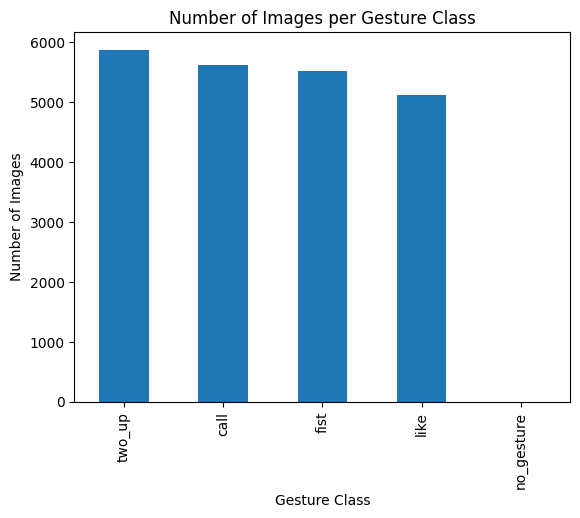

In [38]:
# Creating a plot for the class distribution
df_testing["label"].value_counts().plot(kind="bar")
plt.title("Number of Images per Gesture Class")
plt.xlabel("Gesture Class")
plt.ylabel("Number of Images")
plt.show()

### 4.5. Dealing with class imabalance
The plot and value_counts reveal that the class "no_gesture" has only 1 image assigned to it, making it meaningless to keep it as a training data. Its **suggested** to delete the image with this label.

In [39]:
df_testing = df_testing[~(df_testing["label"] == "no_gesture")]
print(df_testing["label"].value_counts())

label
two_up    5875
call      5618
fist      5515
like      5119
Name: count, dtype: int64


#### **Conclusions:**
**For Missing Images:**
The amount of images that are missing is a 75% of the whole dataset approximately. The amount of images after deleting the missing ones out of the dataframe would be 28340. The images that had 2 annotations (2 hands) when also removed leave the dataframe with 22128 available images. This amount is still pretty useful to train a gesture recognition model.

For the data preparation, the 2 actions done above are recommended.

**For Image Classes:**
The 4 gesture classes we are relatively balanced, only with the problem that there is a single row with a "no_gesture" class. In case for this EDA, the row was deleted for a better analysis.

For data preparation, the action above is recommended.

## 5. New Preprocessing of Images

### Why did we change the previous preprocessing?
For the TP, we didn't knew what exact CNN model we would use, so we did a general preprocessing based on our criteria on what would make the images better for the future CNN we would choose. First, we would select only the whole images of a fixed size, then convert the images to grayscale, then apply CLAHE to the whole image. After that, we crop the images to only keep the part inside the bounding boxes, and then chose a fixed size for this bounding boxes.

For the TF, we decided that we would do a fine tuning of MobileNetV3 Small for our project. MobileNetV3-Small recieves a 224x224x3(RGB) input of the hand. So, the previous preprocessing wasn't correct for MobileNet, so for that reason we have changed the preprocessing so it can match directly the input that MobileNet expects.

In [ ]:
raw_images_root = images_root
output_root = Path("/content/data/mobilenet_hand_crops")
output_root.mkdir(parents=True, exist_ok=True)

### 5.1. Bounding Box increase and cropping.

Our model will expect a image of the hand doing the gesture, with the area inside the bounding box already cropped, so we will directly crop the images first. Also, we will increase the bounding box by a 10%, so its not too tight on the hand (this causes some features of the hand to be lost).

In [ ]:
bbox_increase = 0.10

def crop_from_bounding_boxes(img, row, increase):
    img_h, img_w = img.shape[:2]

    x1 = int(row["bbox_x"] * img_w)
    x2 = int((row["bbox_x"] + row["bbox_w"]) * img_w)
    y1 = int(row["bbox_y"] * img_h)
    y2 = int((row["bbox_y"] + row["bbox_h"]) * img_h)

    bbox_w = x2 - x1
    bbox_h = y2 - y1
    margin_x = int(bbox_w * increase)
    margin_y = int(bbox_h * increase)

    x1 = max(0, x1 - margin_x)
    y1 = max(0, y1 - margin_y)
    x2 = min(img_w, x2 + margin_x)
    y2 = min(img_h, y2 + margin_y)

    if x2 <= x1 or y2 <= y1:
        return None

    return img[y1:y2, x1:x2]

### 5.2. Resizing image
After increasing the bbox and cropping the image of the hand insde, we will now resize this image to the target size that is 224x224x3(The one our model will use). For this, we will apply resizing with padding, so the image resolution ratio doesn't get altered making the image loose its structure.

In [ ]:
def resize_with_padding(img, target_size=224, pad_color=(0, 0, 0)):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.full(
        (target_size, target_size, 3),
        pad_color,
        dtype=np.uint8
    )
    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2
    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    return canvas

### 5.3. Apply the changes
Now we apply the functions we created to do the preprocessing, and save them on the data/processed path

In [ ]:
target_size = 224
bbox_increase = 0.10

mobilenet_rows = []

for _, row in df_testing.iterrows():
    raw_image_path = raw_images_root / row["label"] / f"{row['image_id']}.jpg"
    img = cv2.imread(str(raw_image_path), cv2.IMREAD_COLOR)
    if img is None:
        continue

    hand_crop = crop_hand_from_bbox(img, row, increase=bbox_increase)
    if hand_crop is None:
        continue

    resized_hand = resize_with_padding(hand_crop, target_size=target_size)

    label_dir = output_root / row["label"]
    label_dir.mkdir(parents=True, exist_ok=True)
    output_path = label_dir / f"{row['image_id']}.jpg"
    cv2.imwrite(str(output_path), resized_hand)

    mobilenet_rows.append({
        "image_id": row["image_id"],
        "label": row["label"],
        "raw_image_path": str(raw_image_path),
        "image_path": str(output_path),
        "width": target_size,
        "height": target_size,
        "channels": 3,
        "shape": resized_hand.shape
    })

df_mobilenet_hands = pd.DataFrame(mobilenet_rows)
print(f"MobileNet-ready hand crops created: {df_mobilenet_hands.shape[0]}")

MobileNet-ready hand crops created: 22127


In [43]:
df_mobilenet_hands.head()

,image_id,label,raw_image_path,image_path,width,height,channels,shape
0,018f74c8-2ce6-40e4-9b8e-8a114a7dad56,fist,../data/raw/images/fist/018f74c8-2ce6-40e4-9b8...,../data/mobilenet_hand_crops/fist/018f74c8-2ce...,224,224,3,"(224, 224, 3)"
1,01cb61ac-5e2a-4c7a-ba0e-fa18197352f4,fist,../data/raw/images/fist/01cb61ac-5e2a-4c7a-ba0...,../data/mobilenet_hand_crops/fist/01cb61ac-5e2...,224,224,3,"(224, 224, 3)"
2,01cd940f-d31c-49f6-87a4-dd1f25d73c74,fist,../data/raw/images/fist/01cd940f-d31c-49f6-87a...,../data/mobilenet_hand_crops/fist/01cd940f-d31...,224,224,3,"(224, 224, 3)"
3,02b06b98-5783-4a70-a3ad-fbe3ac627b05,fist,../data/raw/images/fist/02b06b98-5783-4a70-a3a...,../data/mobilenet_hand_crops/fist/02b06b98-578...,224,224,3,"(224, 224, 3)"
4,0403a3a7-d2c5-4db4-940f-2f47e78e27a6,fist,../data/raw/images/fist/0403a3a7-d2c5-4db4-940...,../data/mobilenet_hand_crops/fist/0403a3a7-d2c...,224,224,3,"(224, 224, 3)"


### 5.4. Visualize the preprocessed images

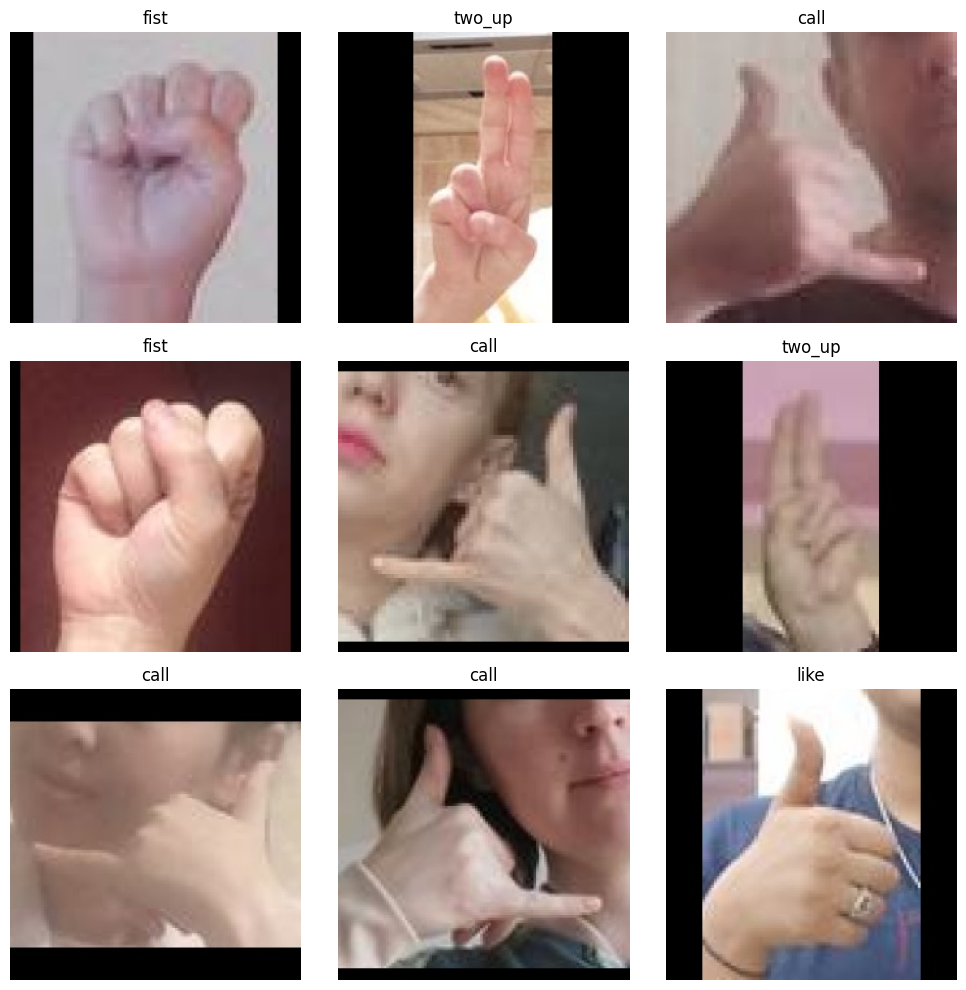

In [44]:
sample = df_mobilenet_hands.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = cv2.imread(row["image_path"], cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### 5.5. Normalizing the images input arrays for MobileNetV3-Small
We also will normalize the intensity of the pixels of the images from 0:255 to 0:1, this is since MobileNetV3-Small usually expects a input like this and gives better results.

In [ ]:
def load_mobilenet_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 127.0 - 1

def mobilenet_image_generator():
    for _, row in df_mobilenet_hands.iterrows():
        img = load_mobilenet_image(row["image_path"])
        if img is None:
            continue

        yield img, row["label"]

df_mobilenet_inputs = df_mobilenet_hands[[
    "image_id",
    "image_path",
    "label",
    "shape",
]].copy()

print(df_mobilenet_inputs["shape"].value_counts())


shape
(224, 224, 3)    22127
Name: count, dtype: int64


## 6. Conclusions

Now that we have the preprocessed images, we will use this processed images to train our model.

---